# 08 — Lighting a small scene

Time to spend the theory. We bake a grid of light probes into a small scene, shade
it entirely from those probes, and compare against a Monte Carlo reference — with
error images and numbers, not vibes.

The last section is the important one: **what light probes cannot do**, and why
every engine pairs them with something else.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

In [2]:
import shscene as ss, time

scene = ss.default_scene(env=ss.sky_studio)
W, H = 420, 290
cam = ss.camera_rays(W, H, eye=(0.0, -7.5, 3.2), target=(0.0, 0.0, 1.0), fov_deg=45)

print("scene:")
for s in scene.spheres:
    print(f"   {s}")
print(f"   ground plane at z = {scene.ground_z}")
print(f"   environment: sky_studio (key/fill/rim)")

scene:
   Sphere(c=[0.0, 0.0, 1.0], r=1.0)
   Sphere(c=[-2.4, 0.9, 0.65], r=0.65)
   Sphere(c=[2.1, -0.7, 0.8], r=0.8)
   ground plane at z = 0.0
   environment: sky_studio (key/fill/rim)


## 1. The reference

Ground truth is a Monte Carlo estimate of the irradiance integral **with shadow
rays**, so inter-object occlusion is included. This is the honest target: what the
scene should actually look like.

ground truth: 512 spp with shadow rays -- 17.2 s


<Axes: title={'left': 'ground truth (512 spp, ray-traced occlusion)'}>

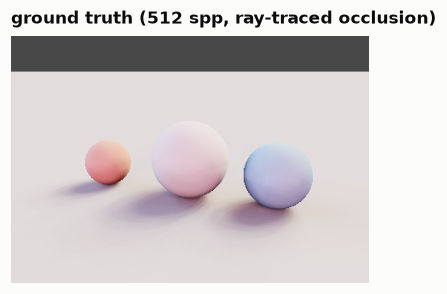

In [3]:
t0 = time.perf_counter()
gt = ss.render(scene, W, H, camera=cam,
               shader=lambda p, n, a: ss.shade_ground_truth(scene, p, n, a,
                                                            spp=512, occlusion=True))
t_gt = time.perf_counter() - t0
print(f"ground truth: 512 spp with shadow rays -- {t_gt:.1f} s")
sp.show_render(gt, "ground truth (512 spp, ray-traced occlusion)", exposure=1.6)

## 2. One probe for the whole scene

The simplest thing that could work: bake a single probe at the origin and light
everything from it.

speedup vs ground truth: 342x
RMS relative error:      22.26%


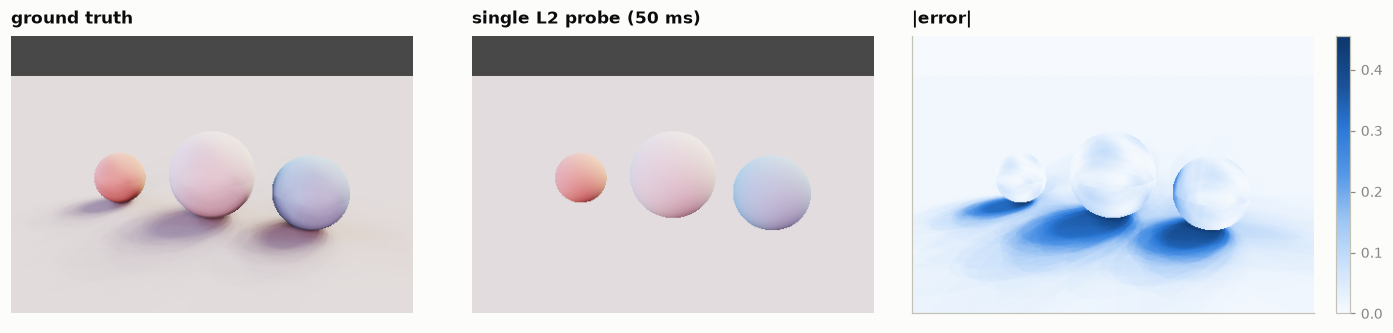

In [4]:
c_single = sh.project_env(scene.env, 2, n_samples=300_000)

t0 = time.perf_counter()
single = ss.render(scene, W, H, camera=cam,
                   shader=lambda p, n, a: ss.shade_sh_probe(c_single, n, a))
t_single = time.perf_counter() - t0

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.0))
sp.show_render(gt, "ground truth", ax=axes[0], exposure=1.6)
sp.show_render(single, f"single L2 probe ({t_single*1000:.0f} ms)", ax=axes[1], exposure=1.6)
im = axes[2].imshow(np.abs(single-gt).mean(-1), cmap=sp.CM_SEQUENTIAL)
axes[2].set_title("|error|"); axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.colorbar(im, ax=axes[2], fraction=0.045)
fig.tight_layout()

print(f"speedup vs ground truth: {t_gt/t_single:.0f}x")
print(f"RMS relative error:      {sh.relative_error(single, gt)*100:.2f}%")

Fast and mostly right, but look at the error image: it concentrates in the
**contact regions** — where spheres meet the ground, and where one sphere shadows
another.

That is expected and it is fundamental. One probe holds one spherical function; it
cannot know that a point under a sphere sees less sky than a point in the open.

## 3. A grid of probes

Bake probes on a 3D grid, each capturing the environment **with occlusion from its
own position**, then trilinearly interpolate the coefficients.

This is legitimate because SH projection is linear — a blend of coefficients is the
coefficient set of the blended lighting.

In [5]:
t0 = time.perf_counter()
positions, coeffs = ss.build_probe_grid(
    scene, bounds_min=(-4.5, -3.5, 0.15), bounds_max=(4.5, 3.5, 3.4),
    counts=(9, 7, 4), lmax=2, n_samples=4096, occlusion=True)
t_bake = time.perf_counter() - t0

n_probes = np.prod(positions.shape[:3])
print(f"baked {n_probes} probes in {t_bake:.1f} s")
print(f"storage: {n_probes} x 9 x 3 floats = {n_probes*27} floats "
      f"= {n_probes*27*2/1024:.1f} KB at fp16")

baked 252 probes in 0.3 s
storage: 252 x 9 x 3 floats = 6804 floats = 13.3 KB at fp16


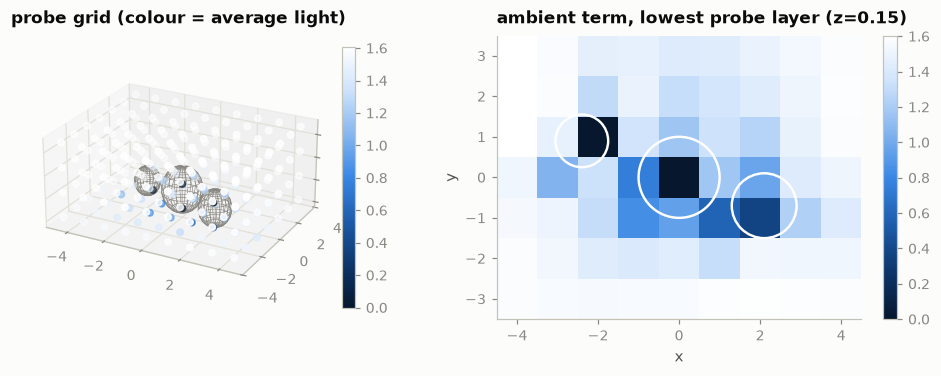

In [6]:
# Where the probes sit, and how their L0 (average) term varies with position.
fig = plt.figure(figsize=(9.5, 3.4))

ax = fig.add_subplot(121, projection="3d")
P = positions.reshape(-1, 3)
amb = coeffs.reshape(-1, 9, 3)[:, 0, :]
bright = amb.mean(-1)
sc = ax.scatter(P[:,0], P[:,1], P[:,2], c=bright, cmap=sp.CM_RADIANCE, s=18)
for s in scene.spheres:
    u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:12j]
    ax.plot_wireframe(s.center[0]+s.radius*np.cos(u)*np.sin(v),
                      s.center[1]+s.radius*np.sin(u)*np.sin(v),
                      s.center[2]+s.radius*np.cos(v), color=sp.MUTED, lw=0.4)
ax.set_title("probe grid (colour = average light)")
ax.set_box_aspect((9,7,4)); ax.view_init(elev=24, azim=-62)
plt.colorbar(sc, ax=ax, fraction=0.03)

ax = fig.add_subplot(122)
slab = coeffs[:, :, 0, 0, :].mean(-1).T        # L0 term, lowest probe layer
m = ax.imshow(slab, cmap=sp.CM_RADIANCE, origin="lower",
              extent=[-4.5, 4.5, -3.5, 3.5])
for s in scene.spheres:
    ax.add_patch(plt.Circle((s.center[0], s.center[1]), s.radius,
                            fill=False, color="white", lw=1.6))
ax.set_title("ambient term, lowest probe layer (z=0.15)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(False)
plt.colorbar(m, ax=ax, fraction=0.04)
fig.tight_layout()

The probes underneath the spheres are measurably darker — they see less sky. That
spatial variation is the only thing distinguishing a probe grid from a single probe,
and it is what produces soft ambient occlusion.

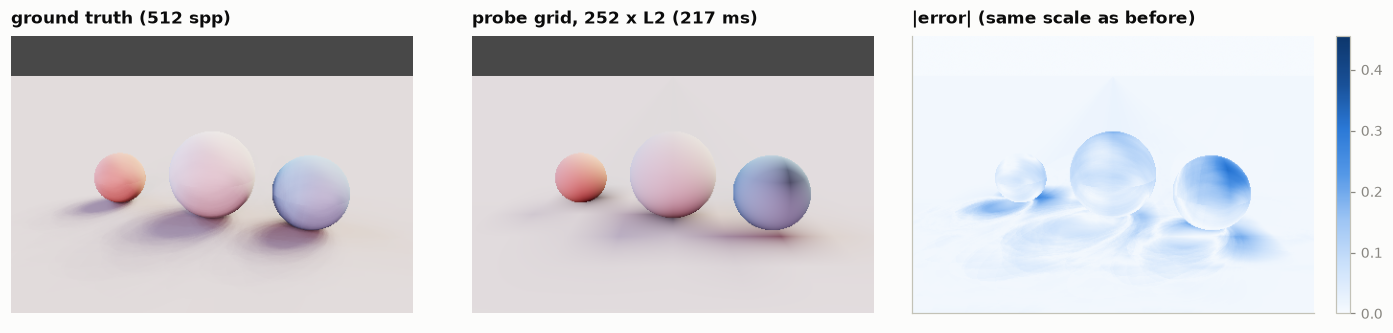

In [7]:
t0 = time.perf_counter()
grid_img = ss.render(scene, W, H, camera=cam,
                     shader=lambda p, n, a: ss.shade_probe_grid(positions, coeffs, p, n, a))
t_grid = time.perf_counter() - t0

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.0))
sp.show_render(gt, "ground truth (512 spp)", ax=axes[0], exposure=1.6)
sp.show_render(grid_img, f"probe grid, {n_probes} x L2 ({t_grid*1000:.0f} ms)",
               ax=axes[1], exposure=1.6)
im = axes[2].imshow(np.abs(grid_img-gt).mean(-1), cmap=sp.CM_SEQUENTIAL,
                    vmax=np.abs(single-gt).mean(-1).max())
axes[2].set_title("|error| (same scale as before)")
axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
plt.colorbar(im, ax=axes[2], fraction=0.045)
fig.tight_layout()

Darkening under and between the spheres now appears, and the error image is visibly
cooler than the single-probe version on the same colour scale.

## 4. The full comparison

In [8]:
c_full = sh.project_env(scene.env, 4, n_samples=300_000)
variants = []

def timed(name, shader, floats):
    t0 = time.perf_counter()
    img = ss.render(scene, W, H, camera=cam, shader=shader)
    variants.append((name, img, time.perf_counter()-t0, floats))

timed("ambient only (L0)", lambda p,n,a: ss.shade_sh_probe(
        np.where(np.arange(9)[:,None] == 0, c_full[:9], 0), n, a), 3)
timed("single probe L1", lambda p,n,a: ss.shade_sh_probe(c_full[:4], n, a), 12)
timed("single probe L2", lambda p,n,a: ss.shade_sh_probe(c_full[:9], n, a), 27)
timed("single probe L4", lambda p,n,a: ss.shade_sh_probe(c_full[:25], n, a), 75)
timed(f"probe grid L2 ({n_probes})",
      lambda p,n,a: ss.shade_probe_grid(positions, coeffs, p, n, a), n_probes*27)

print(f"{'method':<26}{'floats':>9}{'RMS err':>10}{'max err':>10}{'render ms':>11}")
print("-" * 68)
for name, img, dt, fl in variants:
    print(f"{name:<26}{fl:>9,}{sh.relative_error(img,gt)*100:>9.2f}%"
          f"{np.abs(img-gt).max()/gt.max()*100:>9.2f}%{dt*1000:>11.0f}")
print(f"{'ground truth (512 spp)':<26}{'--':>9}{0.0:>9.2f}%{0.0:>9.2f}%{t_gt*1000:>11.0f}")

method                       floats   RMS err   max err  render ms
--------------------------------------------------------------------
ambient only (L0)                 3    40.07%    50.72%         55
single probe L1                  12    26.46%    56.15%         46
single probe L2                  27    22.26%    55.71%         58
single probe L4                  75    23.89%    54.47%         90
probe grid L2 (252)           6,804    11.35%    41.51%        219
ground truth (512 spp)           --     0.00%     0.00%      17201


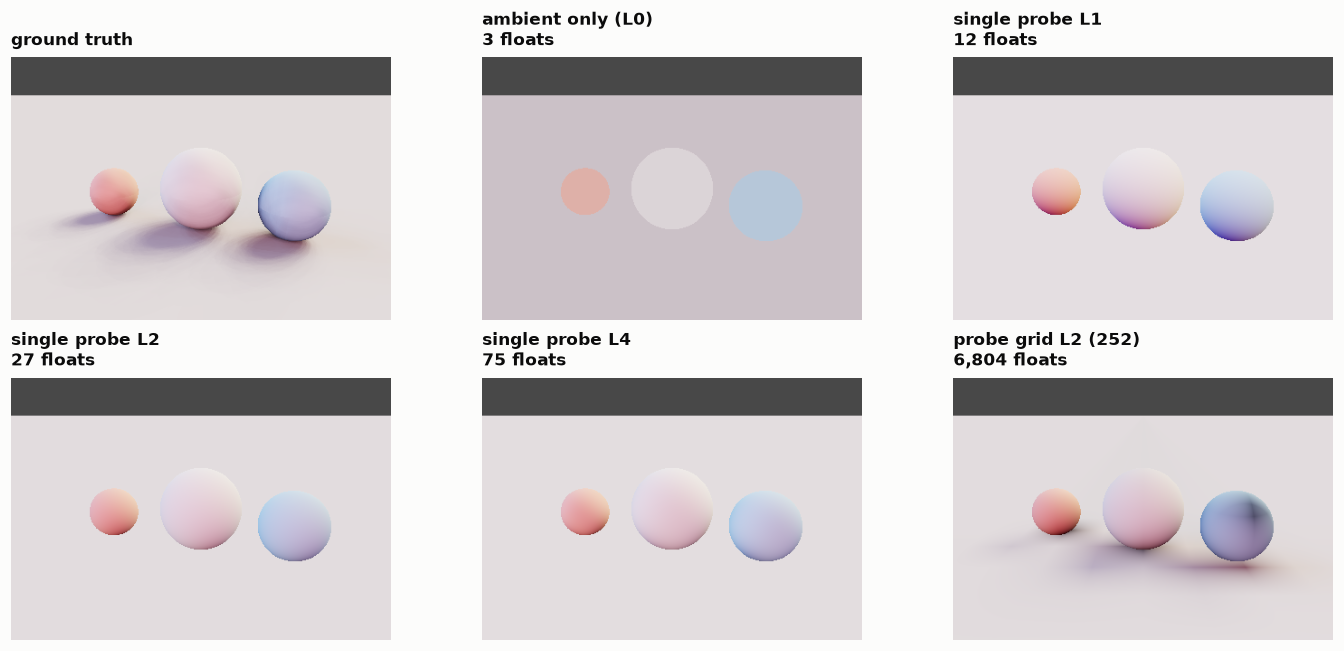

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13.0, 6.0))
sp.show_render(gt, "ground truth", ax=axes[0,0], exposure=1.6)
for ax, (name, img, dt, fl) in zip(axes.ravel()[1:], variants):
    sp.show_render(img, f"{name}\n{fl:,} floats", ax=ax, exposure=1.6)
fig.tight_layout()

Three things worth reading off this table.

**L4 is actually *worse* than L2 here** (23.9% vs 22.3%), not merely no better. That
looks wrong until you notice what the error is made of: against an occluded
reference, a single probe's error is dominated by the shadowing it cannot represent
*at all*. Extra angular bands refine a signal that was never the problem, and the
extra sharpness slightly misfits the (much softer) true shading. Paying 75 floats
instead of 27 buys nothing for diffuse — the empirical justification for L2 being
the industry default.

**The probe grid helps far more than extra bands do** — 22.3% → 11.4%, a genuine
halving, because it attacks the error that actually exists: spatial variation from
occlusion.

**Compare against notebook 06**, where `studio` at L2 scored 4.25%. That measurement
used an *unoccluded* reference. Same probe, same math, 22% here — the difference is
entirely occlusion. When you see an SH accuracy number quoted anywhere, ask what the
reference included.

## 5. What light probes cannot do

Honest limitations, each with the reason:

**No contact shadows.** A probe is a spherical average at a point. Sharp shadow
boundaries are higher frequency than band 2 can express, spatially *and* angularly.
Engines pair probes with shadow maps or SSAO — probes carry the ambient bounce,
something else carries the contact detail.

**Light leaking.** A probe stores no geometry, so interpolation happily carries
light straight through a wall. Let's build one: a solid wall in the $y$–$z$ plane,
lit strongly from the $+X$ side.

The textbook case is a **wall thinner than the probe spacing**. Build one: a thin,
tall wall in the $y$–$z$ plane, lit strongly from $+X$, with probes placed so that
none of them lands inside the wall — every probe here holds a perfectly correct
value.

In [10]:
# A thin (~1 unit) but tall and wide wall at x = 0.
wall_spheres = [ss.Sphere((0.0, y, z), 0.5, (0.5, 0.5, 0.5))
                for y in np.arange(-9.0, 9.1, 0.45)
                for z in np.arange(0.2, 6.5, 0.45)]

def side_light(d):
    d = np.asarray(d, float)
    key = np.clip((d @ np.array([1.0, 0.0, 0.20]) - 0.25) / 0.75, 0, 1)[..., None]
    return np.array([4.0, 3.6, 3.0]) * key**2 + np.array([0.04, 0.05, 0.07])

wall = ss.Scene(spheres=wall_spheres, env=side_light, ground_z=0.0)
print(f"wall built from {len(wall_spheres)} spheres, ~1.0 units thick")

def ambient_along_x(xs, n_samples=4000):
    dirs = sh.fibonacci_sphere(n_samples)
    basis = sh.sh_eval_dirs(2, dirs)
    w = 4*np.pi/n_samples
    out = []
    for x in xs:
        o = np.broadcast_to(np.array([x, 0.0, 1.5]), dirs.shape)
        blocked = ss.intersect_scene(wall, o, dirs)["hit"]
        rad = np.where(blocked[:, None], 0.0, side_light(dirs))
        out.append((w * (basis.T @ rad))[0].mean())
    return np.array(out)

# Probe spacing 1.5, offset so none lands inside the wall.
x_probe = np.array([-3.75, -2.25, -0.75, 0.75, 2.25, 3.75])
a_probe = ambient_along_x(x_probe, 16000)

x_dense = np.linspace(-4.0, 4.0, 81)
a_dense = ambient_along_x(x_dense, 4000)
a_interp = np.interp(x_dense, x_probe, a_probe)   # what a surface receives

wall built from 574 spheres, ~1.0 units thick


     x     true   interpolated   
----------------------------------
 -2.25   0.0747         0.0768   1.0x too bright
 -1.20   0.0529         0.0572   1.1x too bright
 -0.60   0.0482         0.1563   3.2x too bright
 -0.55   0.0477         0.1919   4.0x too bright

lit side reads 1.133 — that is the light being leaked


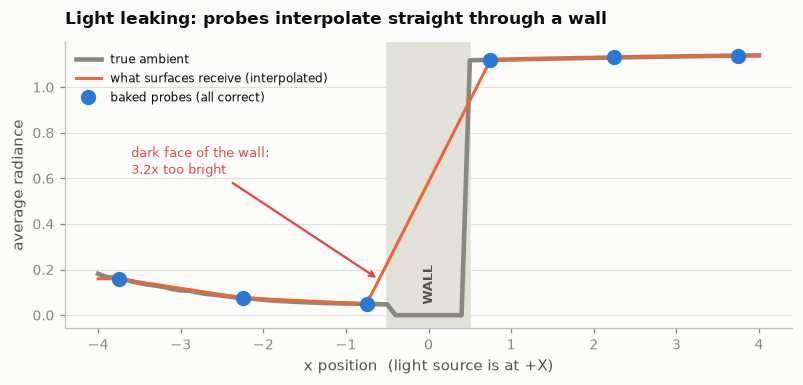

In [11]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.axvspan(-0.5, 0.5, color=sp.GRID, zorder=0)
ax.text(0, 0.06, "WALL", ha="center", fontsize=8.5, weight="bold",
        rotation=90, color=sp.SECONDARY)

ax.plot(x_dense, a_dense, "-", color=sp.MUTED, lw=3.0, label="true ambient")
ax.plot(x_dense, a_interp, "-", color=sp.SERIES[1], lw=2,
        label="what surfaces receive (interpolated)")
ax.plot(x_probe, a_probe, "o", color=sp.SERIES[0], ms=9,
        label="baked probes (all correct)", zorder=5)

t06 = np.interp(-0.6, x_dense, a_dense)
i06 = np.interp(-0.6, x_dense, a_interp)
ax.annotate(f"dark face of the wall:\n{i06/t06:.1f}x too bright",
            xy=(-0.6, i06), xytext=(-3.6, 0.62), fontsize=8.5, color=sp.SERIES[7],
            arrowprops=dict(arrowstyle="->", color=sp.SERIES[7], lw=1.5))

ax.set_xlabel("x position  (light source is at +X)")
ax.set_ylabel("average radiance")
ax.set_title("Light leaking: probes interpolate straight through a wall", pad=12)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

print(f"{'x':>6}{'true':>9}{'interpolated':>15}   ")
print("-" * 34)
for x in (-2.25, -1.20, -0.60, -0.55):
    t = np.interp(x, x_dense, a_dense); i = np.interp(x, x_dense, a_interp)
    print(f"{x:>6.2f}{t:>9.4f}{i:>15.4f}   {i/max(t,1e-9):.1f}x too bright")
print(f"\nlit side reads {a_dense[x_dense > 1.5].mean():.3f} — that is the light being leaked")

Every probe in this figure holds a **correct** value. None is inside geometry. The
error comes entirely from what happens *between* them: a surface pressed against the
dark face of the wall sits close enough to the lit probe at $x=+0.75$ that the blend
hands it more than three times the light it should receive.

The root cause is that interpolation weights depend only on **distance**, never on
**visibility**. The wall is invisible to the interpolator.

Note also that leaking scales with probe spacing relative to feature size: this wall
is 1 unit thick with probes 1.5 apart. Halve the spacing and the leak shrinks;
that is why probe density is a level-art concern, not just a memory one.

Mitigations — denser probes near boundaries, per-probe visibility data, depth-aware
blending, marking probes inside geometry invalid — all amount to smuggling geometric
information back into a representation that deliberately discarded it.

**Only diffuse.** Everything here assumed a Lambertian surface. The cosine lobe's
band collapse is what made 9 coefficients sufficient; a sharp specular lobe is
narrow, so its band coefficients do *not* collapse. Glossy reflections need
prefiltered cubemaps or a different representation entirely.

**Static lighting.** Probes are baked. Moving a light means re-baking. Dynamic
approaches (DDGI, real-time probe update) exist and usually keep SH as the storage
format while recomputing the coefficients each frame.

## 6. Where to take this next

- **Add a real HDR environment** — `imageio` is already installed. Load a lat-long
  `.hdr`, wrap it as an `env_fn(dirs)`, and pass it to `project_env`. Everything in
  this series works unchanged.
- **Try L1 probes throughout** and see where 12 floats visibly fails.
- **Implement per-probe visibility** and watch the leaking demo improve.
- **Port the shader** from notebook 07 into your engine and compare against this
  reference implementation using the convention smoke test.

### Reading

- Ramamoorthi & Hanrahan, *An Efficient Representation for Irradiance Environment
  Maps* (SIGGRAPH 2001) — the core result of notebook 06.
- Green, *Spherical Harmonic Lighting: The Gritty Details* (GDC 2003) — the
  practical graphics introduction.
- Sloan, *Stupid Spherical Harmonics Tricks* (GDC 2008) — ZH, rotation, windowing.
- Sloan, Kautz & Snyder, *Precomputed Radiance Transfer* (SIGGRAPH 2002) — where SH
  lighting goes beyond probes.

### The series in one paragraph

A light probe stores a function on a sphere. Spherical harmonics are the
frequency basis for such functions — orthonormal, so projection is one integral per
coefficient; rotation-closed, so bands survive transformation intact. Diffuse
lighting convolves radiance with a clamped cosine lobe, which in SH is a per-band
scale that zeroes band 3 and crushes everything above it. So irradiance is
inherently a low-frequency signal, nine coefficients per channel capture it to
about a percent for natural lighting, and evaluating it costs one quadratic form.
That is why light probes are 27 floats.